In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


## Importing and preprocessing the land action data



In [2]:
# import the land action data
land_action = pd.read_csv('tables/DecisionsLandManagers.csv')
# preprocess the land action data
land_action['barley']=land_action['barley_food']+land_action['barley_whiskey']
no_water = [water.replace('_water', '') for water in land_action if water.endswith('_water')]
# print(no_water)
columns = list(land_action.columns)
# print(columns)
filtered_bases = [land_use for land_use in no_water if land_use in columns]
c2keep = []
# print(filtered_bases)
for x in filtered_bases:
    no_water = x
    water = x+'_water'
    land_action[x+'_total'] = land_action[x].fillna(0) + land_action[water].fillna(0)
    c2keep.append(x+'_total')
# change the player_role "community" to "farmer" -> we can do this has the action that the community takes is the same as the farmer
land_action['player_role'] = land_action['player_role'].replace('community', 'farmer')
c2keep =  ['id', 'player_id', 'round', 'player_role'] +c2keep
land_action = land_action[c2keep]
# rename column id to GameID
land_action.rename(columns={'id': 'GameID'}, inplace=True)
# rename all columns that have _total to have ""
land_action.rename(columns=lambda x: x.replace('_total', ''), inplace=True)
# rename "native" column to "native woodland"
land_action.rename(columns={'native': 'native woodland'}, inplace=True)
# rename "cattle" to "cow"
land_action.rename(columns={'cow': 'cattle'}, inplace=True)
land_action.head()

,GameID,player_id,round,player_role,sitka,native woodland,deer,grouse,cattle,sheep,potato,barley,fruit
0,1,1,1,estate,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2,1,estate,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
2,1,3,1,farmer,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0
3,1,4,1,farmer,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
4,1,5,1,farmer,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Importing and preprocessing the policy decision data

In [3]:
# import the policy decision data
policies = pd.read_csv('tables/scotcape_policies_clean.csv')
# preprocess the policy decision data
conditions = [
    (policies['Researched?'] == 1) & (policies['discussion_alignment']== 1),
    (policies['Researched?'] == 1),
    (policies['discussion_alignment'] == 1)
]

choice = ['both', 'evidence only', 'interaction only']

policies['decision_basis'] = np.select(conditions, choice, default='intuition only')
policies['decision_basis_is_communication'] = (policies["decision_basis"]== 'interaction only') + (policies["decision_basis"]== 'both')
# we keep only the policies that have subsidy as policy type; we do this as there are no interaction policies of tax type
policies = policies[policies['policy type'] == 'subsidy']
# we keep only relevant columns
policies = policies[['GameID', 'Round', 'target_land_use_1', 'target_group','decision_basis', 'decision_basis_is_communication']]
# we drop the rows that cotain housing in target_land_use_1 has is not an actionable land use
policies = policies[~policies['target_land_use_1'].str.contains('housing', na=False)]
# remove policies that are created after round 4 (included) as we cannot measure their effect
policies = policies[policies['Round'] < 4]
# reset the index of the policies dataframe
policies.reset_index(drop=True, inplace=True)
# use the index as a policy id
policies['policy_id'] = policies.index
policies.head()

,GameID,Round,target_land_use_1,target_group,decision_basis,decision_basis_is_communication,policy_id
0,1,2,native woodland,all,evidence only,False,0
1,1,2,native woodland,all,evidence only,False,1
2,2,1,potato,farmer,evidence only,False,2
3,2,1,potato,farmer,evidence only,False,3
4,2,2,barley,farmer,evidence only,False,4


# Creating the table for the difference in difference analysis

In [4]:
def get_policy_effect_table(land_action, GameID, Round, target_land_use_1, player_role, decision_basis_is_communication, time_window_for_effect=1):
    """    Create a table showing the effect of a policy on land use for a specific game and round.
    Args:
        land_action (DataFrame): DataFrame containing land action data.
        GameID (int): The ID of the game.
        Round (int): The round in which the policy was introduced.
        target_land_use_1 (str): The target land use to analyze.
        player_role (list): List of player roles to include in the analysis.
        decision_basis_is_communication (bool): Whether the decision basis is communication.
        time_window_for_effect (int): The number of rounds after the policy introduction to consider for the effect.
    Returns:
        DataFrame: A DataFrame containing the player IDs, land use before and after the policy, and other relevant information.
    """
    # Filter the land_action DataFrame for the specified GameID, Round, and player_role
    if player_role == 'all':
        player_role = land_action['player_role'].unique()
    else:
        player_role = [player_role] if isinstance(player_role, str) else player_role
    a = land_action.query('round == @Round and GameID == @GameID and player_role in @player_role')[['player_id', target_land_use_1]].rename(columns={target_land_use_1: 'before'})
    Round_after = Round + time_window_for_effect
    b = land_action.query('round == @Round_after and GameID == @GameID and player_role in @player_role')[['player_id', target_land_use_1]].rename(columns={target_land_use_1: 'after'})
    c = pd.merge(a, b, on=['player_id'], suffixes=('_before', '_after'))
    c['GameID'] = GameID
    c['Round'] = Round_after
    c['target_land_use'] = target_land_use_1
    c['decision_basis_is_communication'] = decision_basis_is_communication
    return c

In [5]:
# for each policy in policies, we want to extract the information and create a dataframe using get_policy_effect_table
policy_effect_tables = []
for index, row in policies.iterrows():
    policy_effect_table = get_policy_effect_table(
        land_action=land_action,
        GameID=row['GameID'],
        Round=row['Round'],
        target_land_use_1=row['target_land_use_1'],
        player_role=row['target_group'],
        decision_basis_is_communication=row['decision_basis_is_communication'],
    )
    policy_effect_tables.append(policy_effect_table)

# concatenate all the policy effect tables into one dataframe
policy_effect_df = pd.concat(policy_effect_tables, ignore_index=True)
# show the head of the dataframe
policy_effect_df.head()

,player_id,before,after,GameID,Round,target_land_use,decision_basis_is_communication
0,1,1.0,1.0,1,3,native woodland,False
1,2,1.0,1.0,1,3,native woodland,False
2,3,0.0,0.0,1,3,native woodland,False
3,4,2.0,2.0,1,3,native woodland,False
4,5,1.0,1.0,1,3,native woodland,False


# Perfoming the difference in difference analysis

In [7]:
import pandas as pd
import statsmodels.formula.api as smf


# 1) Reshape from wide (before/after) to long
df_long = pd.melt(
    policy_effect_df.reset_index(drop=True),
    id_vars=['decision_basis_is_communication', 'GameID', 'target_land_use','player_id', 'Round'],   # add other id vars if you have them (e.g., 'unit_id')
    value_vars=['before', 'after'],
    var_name='time',
    value_name='outcome'
)

df_long['time'] = df_long['time'].map({'before': 0, 'after': 1})

# If treatment column isn't boolean, force it:
df_long['treated'] = df_long['decision_basis_is_communication'].astype(int)

#make GameID as control variable
df_long['GameID'] = df_long['GameID'].astype('category')

#target_land_use as control variable
df_long['target_land_use'] = df_long['target_land_use'].astype('category')

#Round as control variable
df_long['Round'] = df_long['Round'].astype('category')

# player_id as fixed effect
df_long['player_id'] = df_long['player_id'].astype('category')

# 3) Run the DiD regression
# outcome ~ time + treated + time:treated
model = smf.ols('outcome ~ time + treated + time:treated', data=df_long).fit(cov_type='HC1')

print(model.summary())

# 4) Extract the DiD estimate (interaction term) and its stats
term = 'time:treated'
did_coef = model.params[term]
did_se = model.bse[term]
did_p = model.pvalues[term]
did_ci = model.conf_int().loc[term].tolist()  # 95% CI by default

print("\nDifference-in-Difference results (interaction term = time:treated):")
print(f"Estimate (beta): {did_coef:.6f}")
print(f"Std. Error:         {did_se:.6f}")
print(f"P-value:            {did_p:.6f}")
print(f"95% CI:             [{did_ci[0]:.6f}, {did_ci[1]:.6f}]")


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     14.80
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           5.23e-09
Time:                        09:49:56   Log-Likelihood:                -571.47
No. Observations:                 302   AIC:                             1151.
Df Residuals:                     298   BIC:                             1166.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8369      0.113      7.425   

In [13]:
# Adding GameID and target_land_use as control variable
model = smf.ols('outcome ~ time + treated + time:treated + GameID + target_land_use + Round', data=df_long).fit(cov_type='HC1')

print(model.summary())

# 4) Extract the DiD estimate (interaction term) and its stats
term = 'time:treated'
did_coef = model.params[term]
did_se = model.bse[term]
did_p = model.pvalues[term]
did_ci = model.conf_int().loc[term].tolist()  # 95% CI by default

print("\nDifference-in-Difference results (interaction term = time:treated):")
print(f"Estimate (beta): {did_coef:.6f}")
print(f"Std. Error:         {did_se:.6f}")
print(f"P-value:            {did_p:.6f}")
print(f"95% CI:             [{did_ci[0]:.6f}, {did_ci[1]:.6f}]")


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     14.20
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           5.37e-28
Time:                        09:50:12   Log-Likelihood:                -539.20
No. Observations:                 302   AIC:                             1112.
Df Residuals:                     285   BIC:                             1175.
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [14]:
# Adding player_id and target_land_use as control variable
model = smf.ols('outcome ~ time + treated + time:treated + target_land_use + player_id + Round', data=df_long).fit(cov_type='HC1')

print(model.summary())

# 4) Extract the DiD estimate (interaction term) and its stats
term = 'time:treated'
did_coef = model.params[term]
did_se = model.bse[term]
did_p = model.pvalues[term]
did_ci = model.conf_int().loc[term].tolist()  # 95% CI by default

print("\nDifference-in-Difference results (interaction term = time:treated):")
print(f"Estimate (beta): {did_coef:.6f}")
print(f"Std. Error:         {did_se:.6f}")
print(f"P-value:            {did_p:.6f}")
print(f"95% CI:             [{did_ci[0]:.6f}, {did_ci[1]:.6f}]")


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     9.314
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           3.01e-34
Time:                        09:50:20   Log-Likelihood:                -520.71
No. Observations:                 302   AIC:                             1139.
Df Residuals:                     253   BIC:                             1321.
Df Model:                          48                                         
Covariance Type:                  HC1                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [15]:
# policy_effect_df.melt(id_vars=["decision_basis_is_communication"], 
#                                         value_vars=["before", "after"], 
#                                         var_name='Time', 
#                                         value_name='Value')

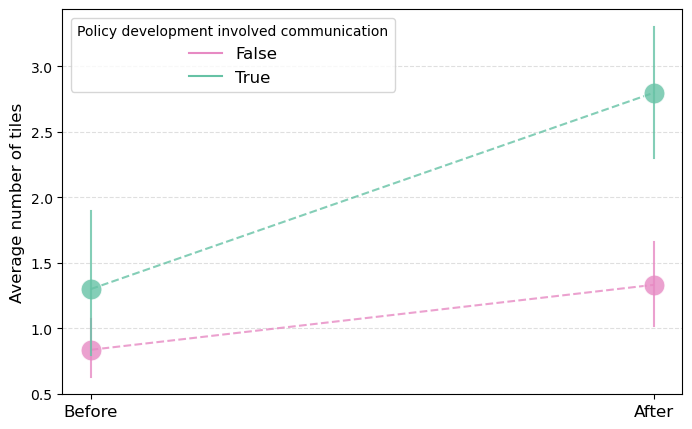

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_difference_in_difference(df, before_col='before', after_col='after', treatment_col='decision_basis_is_communication'):
    """Plot the before and after values for the treated and control groups.
    
    Args:
        df (DataFrame): The DataFrame containing the data.
        before_col (str): The name of the column representing the before values.
        after_col (str): The name of the column representing the after values.
        treatment_col (str): The name of the column indicating the treatment group.
    """
    # Create a new DataFrame for plotting
    plot_data = df.melt(id_vars=[treatment_col], value_vars=[before_col, after_col], 
                        var_name='Time', value_name='Value')
    
    colors = {True: '#66c2a5', False: '#e78ac3'}

    # Create a line plot using seaborn
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=plot_data, x='Time', y='Value', hue=treatment_col, linestyle="--",
                 marker='o', palette=colors, err_style="bars", markersize=15, alpha=0.8)
    
    # Calculate means
    treated_before = df.loc[df[treatment_col]==True, before_col].mean()
    control_before = df.loc[df[treatment_col]==False, before_col].mean()
    control_after = df.loc[df[treatment_col]==False, after_col].mean()

    # The control group's change
    control_diff = control_after - control_before

    # Counterfactual for treated after (if no treatment effect)
    treated_counterfactual_after = treated_before + control_diff

    # Add dashed line for treated counterfactual
    # plt.plot(
    #     [0, 1], 
    #     [treated_before, treated_counterfactual_after], 
    #     linestyle='--', color="darkgrey"
    # )

    plt.xlabel('', fontsize=14)
    plt.xticks([0,1],["Before", "After"], fontsize=12)
    plt.ylabel('Average number of tiles', fontsize=12)
    plt.legend(title="Policy development involved communication", loc='upper left', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()
plot_difference_in_difference(policy_effect_df, before_col='before', after_col='after', treatment_col='decision_basis_is_communication')